# Приоритизация гипотез и анализ проведения А/В-теста для крупного интернет-магазина

**Цели:** 
- Проанализировать список гипотез от отдела маркетинга для увеличения выручки интернет-магазина
- Проанализировать кумулятивную выручку и кумулятивный средний чек по сегментам
- Проанализировать кумулятивное среднее количество заказов на посетителя по группам
- Проанализировать количество заказов по пользователям и стоимости заказов, а так же установить для них границу аномальных значений
- Посчитать статистическую значимость различий в среднем количестве заказов на посетителя между группами и различий в среднем чеке заказа между группами по «сырым» данным
- Посчитать статистическую значимость различий в среднем количестве заказов на посетителя между группами и различий в среднем чеке заказа между группами по «очищенным» данным
- Принять решение об остановке или продолжении теста

**Задачи:**
- Определить наиболее важные гипотезы методами ICE и RICE
- Провести А/В-тест
- Проанализировать результаты

**Описание данных:**
* Файл `/datasets/hypothesis.csv` содержит 9 гипотез по увеличению выручки интернет магазина с указанными параметрами Reach, Impact, Confidence, Effort
* Файлы `/datasets/orders.csv` и `/datasets/visitors.csv` содержат информацию о результатах проведения А/В-теста

Файл `/datasets/hypothesis.csv`:
- `Hypothesis` — краткое описание гипотезы;
- `Reach` — охват пользователей по 10-балльной шкале;
- `Impact` — влияние на пользователей по 10-балльной шкале;
- `Confidence` — уверенность в гипотезе по 10-балльной шкале;
- `Efforts` — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.

Файл `/datasets/orders.csv`:
- `transactionId` — идентификатор заказа;
- `visitorId` — идентификатор пользователя, совершившего заказ;
- `date` — дата, когда был совершён заказ;
- `revenue` — выручка заказа;
- `group` — группа A/B-теста, в которую попал заказ.

Файл `/datasets/visitors.csv`:
- `date` — дата;
- `group` — группа A/B-теста;
- `visitors` — количество пользователей в указанную дату в указанной группе A/B-теста.

## Подготовка данных к анализу

In [1]:
#импортируем все необходимые библиотеки
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_colwidth', 1000) #опция для вывода безлимитной ширины колонки
plt.style.use('seaborn') #зададим стиль графиков

Выведем на экран фрейм с гипотезамии, изучим его и вывдем общую информацию по нему.

In [2]:
#загрузим данные файла с гипотезами
try:
    hypothesis = pd.read_csv('/datasets/hypothesis.csv')
except:
    hypothesis = pd.read_csv('https://code.s3.yandex.net/datasets/hypothesis.csv')

In [3]:
#функция для изучения данных датафрейма
def show_info(df):
    print('Первые 5 строк датафрейма:')
    print('-'*80)
    display(df.head())
    print('-'*80)
    print('Общая информация о датафрейме:')
    print('-'*80)
    print(df.info())
    print('-'*80)
    print('Статистические данные:')
    print('-'*80)
    print(df.describe())
    print('-'*80)
    print('Наличие пропусков в датафрейме:')
    print('-'*80)
    print(df.isna().sum())
    print('-'*80)
    print('Наличие дубликатов: {}'.format(df.duplicated().sum()))

In [4]:
show_info(hypothesis)

Первые 5 строк датафрейма:
--------------------------------------------------------------------------------


,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1


--------------------------------------------------------------------------------
Общая информация о датафрейме:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
None
--------------------------------------------------------------------------------
Статистические данные:
--------------------------------------------------------------------------------
           Reach     Impact  Confidence    Efforts
count   9.000000   9.000000    9.000000   9.000000
mean    4.777778   4.777778    5.555556   4.888889
std     3.153481   3.192874  

Дубликаты и пропуски в датафрейме отсутствуют. Также отсутствуют и аномалии. Все типы данных совпадают с ожидаемыми. Единственное, необходимо привести названия колонок к нижнему регистру.

In [5]:
#приведем названия колонок к нижнему регистру и выведем весь датафрейм
hypothesis.columns = hypothesis.columns.str.lower()

display(hypothesis)

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


Привели названия колонок к стандартному виду. Название каждой колонки имеет нижний регистр.

Далее выведем на экран фреймы с заказами и посетителями, изучим их и вывдем общую информацию по ним.

In [6]:
#загрузим данные файлов с заказами и посетителями
try:
    orders, visitors = (
        pd.read_csv('/datasets/orders.csv'),
        pd.read_csv('/datasets/visitors.csv')
    )
except:
    orders, visitors = (
        pd.read_csv('https://code.s3.yandex.net/datasets/orders.csv'),
        pd.read_csv('https://code.s3.yandex.net/datasets/visitors.csv')
    )

Изучим датафрейм с заказами.

In [7]:
#применяем функцию для изучения информации
show_info(orders)

Первые 5 строк датафрейма:
--------------------------------------------------------------------------------


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


--------------------------------------------------------------------------------
Общая информация о датафрейме:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB
None
--------------------------------------------------------------------------------
Статистические данные:
--------------------------------------------------------------------------------
       transactionId     visitorId       revenue
count   1.197000e+03  1.197000e+03  1.197000e+03
mean    2.155621e+09  2.165960e+09  8.348006e+03
std     1.22

Видим, что названия первых двух колонок `transactionId` и `visitorId` не стандартны. Переназовем их.

In [8]:
#переназываем колонки
orders = orders.rename(columns = {'transactionId': 'transaction_id', 'visitorId': 'visitor_id'}, inplace = False)

Приведем кололнку с датой `date` к типу datetime вместо object. 

In [9]:
#меняем тип данных
orders['date'] = pd.to_datetime(orders['date'], format='%Y-%m-%d')
#проверяем замену
print(orders['date'].dtype)

datetime64[ns]


Проверим колонку с выручкой `revenue` на наличие аномалий. Для этого построим диаграмму размаха.

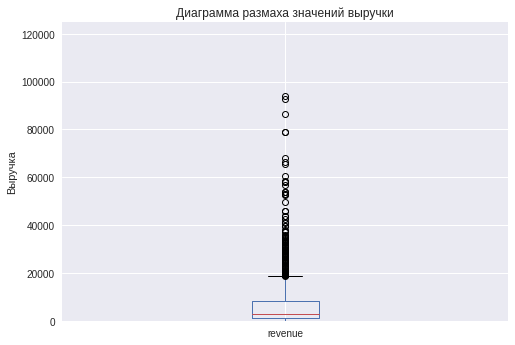

In [10]:
orders.boxplot(column=['revenue'])
plt.ylabel('Выручка')
plt.title('Диаграмма размаха значений выручки')
plt.ylim(0, 125000)
plt.show()

Видим,что основной диапазон значений выручки лежит до 20000 рублей. Остальные значения диаграмма видит как выбросы, есть также 2 очень больших выброса в области 200000 и 1200000 рублей.

Во фрейме с заказами не было выявлено дубликатов и пропусков. В колонке `date` был неверный тип данных, привели ее к типу datetime. В первых двух колонках фрейма были нестандартные названия, привели их к стандартным. Также выявили большое количество выбросов в колонке с выручкой. Оставим эти значения и не будем удалять, так как заказы на такие суммы действительно единично могли быть. В дальнейшем при анализе проведения теста будем использовать методы, устойчивые к выбросам.

Изучим датафрейм с посетителями.

In [11]:
#применяем функцию для изучения информации
show_info(visitors)

Первые 5 строк датафрейма:
--------------------------------------------------------------------------------


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


--------------------------------------------------------------------------------
Общая информация о датафрейме:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None
--------------------------------------------------------------------------------
Статистические данные:
--------------------------------------------------------------------------------
         visitors
count   62.000000
mean   607.290323
std    114.400560
min    361.000000
25%    534.000000
50%    624.500000
75%    710.500000
max    770.000000
--------------------------------------------------------------------------------
Наличие пропусков в датафрейме:


Во фрейме с посетителями нет пропусков и дубликатов, а также аномалий. Названия колонок в стандартном виде. В колонке с датой `date` неверный тип данных object, его нужно заменить на datetime.

In [12]:
#меняем тип данных
visitors['date'] = pd.to_datetime(visitors['date'], format='%Y-%m-%d')
#проверяем замену
print(visitors['date'].dtype)

datetime64[ns]


Тип данных заменен успешно.

**Выводы по разделу:**
- Во всех датафреймах отсутствовали дубликаты и пропуски.
- Аномалии отсутствовали во фреймах с гипотезами и посетителями. Во фрейме с заказами в колонке `revenue` найдено много выбросов, от которых мы не стали избавляться, так как покупатели могли действительно оформлять заказы на высокие суммы, а мы в дальнейшем будем использовать методы, устойчивые к выбросам.
- В таблице с гипотезами привели названия колонок к нижнему регистру, а в таблице с заказами заменили названия первых двух колонок на более удобные и стандартные.
- В таблицах с заказами и посетителями в колонке с датой `date` заменили тип данных на datetime.

## Приоритизация гипотез

Для того, чтобы правильно распределить ресурсы на проверку гипотез и максимизировать ожидаемое улучшение ключевых метрик, нам необходимо выделить наиболее важные гипотезы для проверки.

Самыми популярными способами приоритизации задач являются фреймворки ICE и RICE.

Фреймворки состоят из следующих компонент:
- *Reach* — скольких пользователей затронет изменение, которое вы хотите внести;
- *Impact* — насколько сильно изменение повлияет на пользователей, их опыт и удовлетворение от продукта;
- *Confidence* — насколько вы уверены, что это изменение повлияет на пользователей именно так;
- *Efforts* — сколько стоит протестировать эту гипотезу.

Каждый параметр оценивается в нашем случае по шкале от 0 до 10.

Выведем полный фрейм с гипотезами и их оценками.

In [13]:
display(hypothesis)

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


Всего в нашем списке 9 гипотез, которые могут помочь интернет-магазину увеличить выручку. Приступим к их приоритизации.

### Приоритизация гипотез фреймворком ICE

ICE рассчитывается по формуле:

**ICE = (impact * confidence) / efforts**

Произведем расчет параметра и добавим значения в новую колонку.

In [14]:
#расчитаем ICE
hypothesis['ice'] = ((hypothesis['impact'] * hypothesis['confidence']) / hypothesis['efforts']).round(2)
#выведем на экран приоритизированные гипотезы, отсортировав их по убыванию ICE
display(hypothesis[['hypothesis', 'ice']].sort_values(by='ice', ascending=False))

,hypothesis,ice
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.00


При приоритизации с помощью фреймворка ICE в лидерах оказались гипотезы №8 "Запустить акцию, дающую скидку на товар в день рождения", №0 "Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей" и №7 "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок". 

Гипотезы №5 "Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов", №3 "Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар" и №4 "Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей" получили наименьшее количество баллов.

### Приоритизация гипотез фреймворком RICE

RICE содержит в своей формуле все 4 показателя: Reach, Impact, Confidence и Efforts. Фреймворк рассчитывается по формуле:

**RICE = (reach * impact * confidence) / efforts**

Произведем расчет фреймворка и добавим значения в новую колонку.

In [15]:
#расчитаем RICE
hypothesis['rice'] = ((hypothesis['reach'] * hypothesis['impact'] * hypothesis['confidence']) / hypothesis['efforts']).round(2)
#выведем на экран приоритизированные гипотезы, отсортировав их по убыванию RICE
display(hypothesis[['hypothesis', 'rice']].sort_values(by='rice', ascending=False))

,hypothesis,rice
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3.0


В следствие того, что формулы фреймворков разные, приоритизация изменилась.

При применении RICE в лидерах оказались гипотезы №7 "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок", №2 "Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа". Гипотезы №0 "Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей" и №6 "Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию" получили одинаковое количество баллов и оказались на 3 месте по важности. 

В аутсайдеры вышли гипотезы №1 "Запустить собственную службу доставки, что сократит срок доставки заказов", №5 "Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов", №4 "Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей".

### Различия в приоритизации гипотез методами ICE и RICE

Для наглядности параметров построим тепловую карту присвоенных баллов гипотезам.

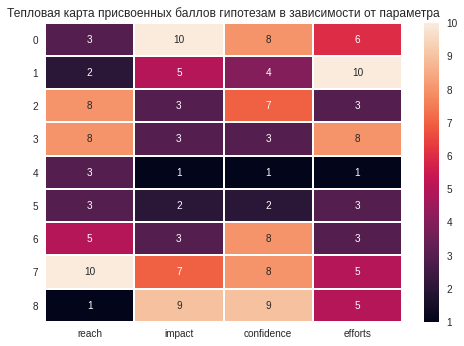

In [16]:
ax = sns.heatmap(hypothesis[['reach', 'impact', 'confidence', 'efforts']], annot=True, linecolor='white', linewidths=1)
plt.yticks(rotation=0)
plt.title('Тепловая карта присвоенных баллов гипотезам в зависимости от параметра')
plt.show()

Изменения в приоритизации двумя методами связаны с тем, что при расчете фреймворка RICE появляется дополнительный важный параметр Reach, который показывает, скольких пользователей затронут изменения.

**Вывод по разделу:** Проведя приоритизацию гипотез фреймворками ICE и RICE, и , выделив лидеров среди гипотез, можем рекомендовать к тестированию гипотезы №7 "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок" и №0 "Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей". 

У гипотезы №7 самый высокий балл Reach, что говорит о том, что изменения затронут очень много пользователей, высокий балл влияния на пользователей и уверенности в том, что изменения повлияют положительно, так же средний балл на затраты для ее тестирования. 

У гипотезы №0 параметр Reach низковат, что значит, что изменения затронут немногих пользователей, но при этом высший балл по влиянию на пользователя и высокий балл уверенности в этом влиянии, при этом затраты на ее тестирования также на среднем уровне.

## Анализ A/B-теста

### Расчет кумулятивной выручки по группам

Для начала подготовим данные для кумулятивных расчетов и построения графиков.

Создадим массив уникальных пар значений дат и групп теста.

In [17]:
#создаем массив уникальных пар значений дат и групп теста
dates_groups = orders[['date', 'group']].drop_duplicates()

Соберём агрегированные кумулятивные по дням данные о заказах и посетителях интернет-магазина.

In [18]:
#получим агрегированные кумулятивные по дням данные о заказах
orders_aggregated = dates_groups.apply(lambda x: orders[np.logical_and(orders['date'] <= x['date'], \
orders['group'] == x['group'])].agg({'date': 'max', 'group': 'max', 'transaction_id': 'nunique', \
'visitor_id': 'nunique', 'revenue': 'sum'}), axis=1).sort_values(by=['date', 'group'])

#получим агрегированные кумулятивные по дням данные о посетителях интернет-магазина
visitors_aggregated = dates_groups.apply(lambda x: visitors[np.logical_and(visitors['date'] <= x['date'], \
visitors['group'] == x['group'])].agg({'date': 'max', 'group': 'max', 'visitors': 'sum'}), \
axis=1).sort_values(by=['date', 'group'])

Обединим две собранные таблицы с агрегированными данными в одну.

In [19]:
#объединим кумулятивные данные в одной таблице
cumulative_data = orders_aggregated.merge(visitors_aggregated, left_on=['date', 'group'], right_on=['date', 'group'])
#дадим названия колонкам
cumulative_data.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']
#выведем первые 5 строк
cumulative_data.head()

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,24,20,148579,719
1,2019-08-01,B,21,20,101217,713
2,2019-08-02,A,44,38,242401,1338
3,2019-08-02,B,45,43,266748,1294
4,2019-08-03,A,68,62,354874,1845


Построим графики кумулятивной выручки по дням и группам A/B-тестирования.

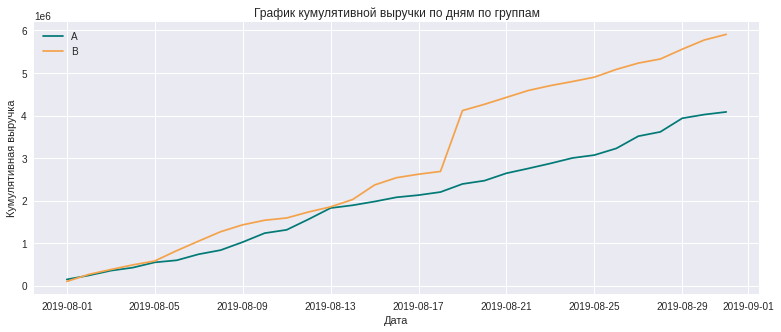

In [20]:
#датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_A = cumulative_data[cumulative_data['group'] == 'A'][['date', 'revenue', 'orders']]
#датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_B = cumulative_data[cumulative_data['group'] == 'B'][['date', 'revenue', 'orders']]

#зададим размер графика
plt.figure(figsize=(13, 5))
#построим график кумулятивной выручки группы А
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['revenue'], label='A', color='#027A76')
#построим график кумулятивной выручки группы B
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['revenue'], label='B', color='#F4A34C')
plt.title('График кумулятивной выручки по дням по группам')
plt.xlabel('Дата')
plt.ylabel('Кумулятивная выручка')
plt.legend()
plt.show()

На протяжении всего теста кумулятивная выручка сегмента А увеличивалась равномерно. Кумулятивная выручка сегмента В на протяжении практически всего теста была выше кумулятивной выручки сегмента А, и при этом совершила резкий скачок в середине теста 18 августа 2019 года. Можем предположить, что данный скачок может быть вызван аномально большими заказами, которые влияют на результат.

### Расчет кумулятивного среднего чека по группам

Построим график кумулятивного среднего чека по группам.

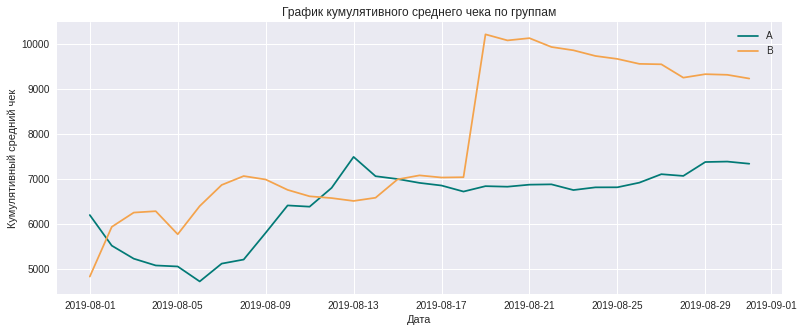

In [21]:
#зададим размер графика
plt.figure(figsize=(13, 5))
#разделим кумулятивную выручку на кумулятивное число заказов группы А
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['revenue'] / cumulative_revenue_A['orders'], label='A', color='#027A76')
#разделим кумулятивную выручку на кумулятивное число заказов группы B
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['revenue'] / cumulative_revenue_B['orders'], label='B', color='#F4A34C')
plt.title('График кумулятивного среднего чека по группам')
plt.xlabel('Дата')
plt.ylabel('Кумулятивный средний чек')
plt.legend()
plt.show()

Практически на всем протяжении теста кумулятивный средний чек группы В превышал группу А. У группы А средний чек установился после подъема 13.08 и имел тенденцию к росту. У группы В кумулятивный средний чек установился после очень резкого скачка 18.08 и далее имел тенденцию к небольшому снижению, при этом оставался намного выше группы А. И снова такой резкий всплеск говорит нам о том, что во второй половине теста в группу В попали аномально крупные заказы, что влияет на результат, группе нужно больше данных.

### Расчет относительного изменения кумулятивного среднего чека группы B к группе A

Построим график относительного изменения кумулятивного среднего чека группы B к группе A.

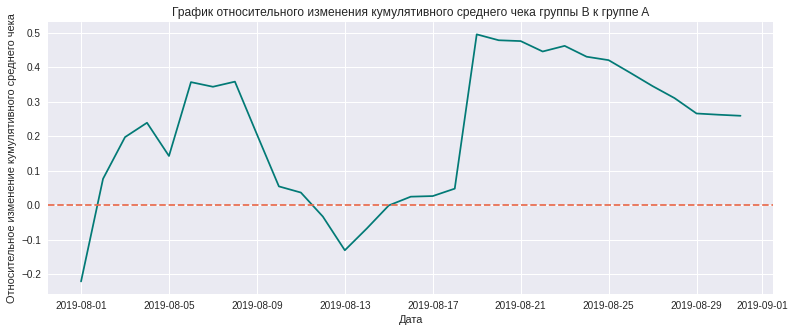

In [22]:
#собираем данные в одном датафрейме
merged_cumulative_revenue = cumulative_revenue_A.merge(cumulative_revenue_B, left_on='date', right_on='date', \
how='left', suffixes=['A', 'B'])

#зададим размер графика
plt.figure(figsize=(13, 5))
#поcтроим график отношения средних чеков
plt.plot(merged_cumulative_revenue['date'], (merged_cumulative_revenue['revenueB'] / merged_cumulative_revenue['ordersB']) / \
(merged_cumulative_revenue['revenueA'] / merged_cumulative_revenue['ordersA']) - 1, color='#027A76')
plt.axhline(y=0, color='#E86C4F', linestyle='--')
plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Относительное изменение кумулятивного среднего чека')
plt.show()

График различия кумулятивного среднего чека резко "скачет" сразу в несколько дат со 02.08 по 08.08 и 19.08. По нашим предположениям в эти даты могли быть сделаны аномально крупные заказы.

### Расчет кумулятивного среднего количества заказов на посетителя по группам

Расчитаем кумулятивное среднее количества заказов на посетителя по группам.

In [23]:
#расчитаем среднее количество заказов на посетителя
cumulative_data['conversion'] = cumulative_data['orders'] / cumulative_data['visitors']

Разделим данные по группам.

In [24]:
#отделяем данные по группе A
cumulative_data_A = cumulative_data[cumulative_data['group'] == 'A']
#отделяем данные по группе B
cumulative_data_B = cumulative_data[cumulative_data['group'] == 'B']

Построим графики.

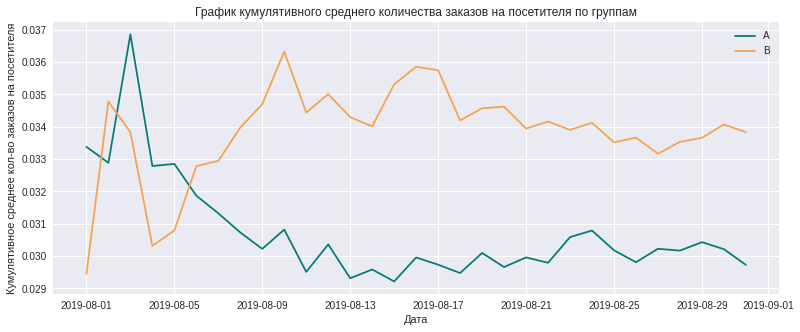

In [25]:
#зададим размер графика
plt.figure(figsize=(13, 5))
#строим график кумулятивного среднего количества заказов на посетителя по группам
plt.plot(cumulative_data_A['date'], cumulative_data_A['conversion'], label='A', color='#027A76')
plt.plot(cumulative_data_B['date'], cumulative_data_B['conversion'], label='B', color='#F4A34C')
plt.title('График кумулятивного среднего количества заказов на посетителя по группам')
plt.legend()
plt.ylabel('Кумулятивное среднее кол-во заказов на посетителя')
plt.xlabel('Дата')
plt.show()

В начале теста конверсия группы А была выше. До 04.08 были некие скачки. После этой даты конверсия группы А снизилась и до конца теста колебалась вокруг отметки 3%. Конверсия группы В, наоборот, резко "скакнула" к 10.08 до отметки чуть выше 3,6% , но дальше начала несущественно снижаться и до конца теста колебалась около отметки примерно 3,4%.

### Расчет относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

Построим график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A.

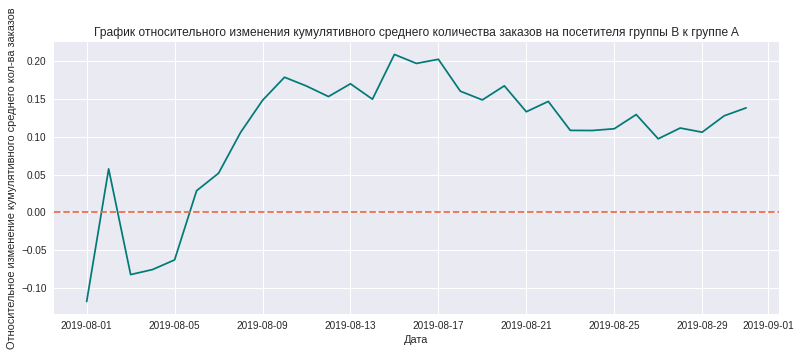

In [26]:
#собираем данные в одном датафрейме
merged_cumulative_conversions = cumulative_data_A[['date', 'conversion']].merge(cumulative_data_B[['date', 'conversion']], \
left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

#зададим размер графика
plt.figure(figsize=(13, 5))
#строим график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A
plt.plot(merged_cumulative_conversions['date'], merged_cumulative_conversions['conversionB'] / \
         merged_cumulative_conversions['conversionA'] - 1, color='#027A76')
plt.axhline(y=0, color='#E86C4F', linestyle='--')
plt.title('График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A')
plt.ylabel('Относительное изменение кумулятивного среднего кол-ва заказов')
plt.xlabel('Дата')
plt.show()

В начале теста группа В проигрывала группе А, но затем существенно вырвалась вперед с 06.08. Кумулятивное среднее количество заказов на посетителя для группы В но с 19.08 начало снижаться, тем не менее, в последние дни теста вновь видна тенденция к росту.

В общей картине, отношение среднего количества заказов на посетителя к концу теста так и не смогло установиться и зафиксироваться. Поэтому делать выводы на данном этапе по тесту еще рано. Для начала нужно проанализировать аномалии.

###  График количества заказов по пользователям

Подсчитаем количество заказов по пользователям и посмотрим на результат.

In [27]:
#расчитываем количество заказов по пользователям
orders_by_users = (
    orders.groupby('visitor_id', as_index=False)
          .agg({'transaction_id': 'nunique'})
)
orders_by_users.columns = ['visitor_id', 'orders']
display(orders_by_users.sort_values(by='orders', ascending=False).head(10))

,visitor_id,orders
1023,4256040402,11
591,2458001652,11
569,2378935119,9
487,2038680547,8
44,199603092,5
744,3062433592,5
55,237748145,5
917,3803269165,5
299,1230306981,5
897,3717692402,5


Есть пользователи, которые совершали 5, 8, 9 и 11 заказов.

Построим гистрограмму распределения количества заказов на одного пользователя.

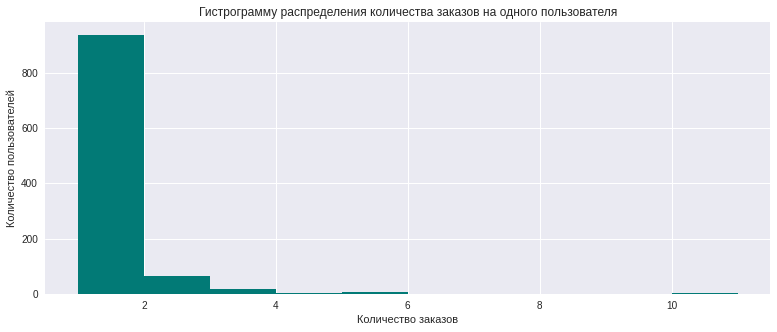

In [28]:
#зададим размер графика
plt.figure(figsize=(13, 5))
#строим гистограмму распределения количества заказов на одного пользователя
plt.hist(orders_by_users['orders'], color='#027A76')
plt.title('Гистрограмму распределения количества заказов на одного пользователя')
plt.ylabel('Количество пользователей')
plt.xlabel('Количество заказов')
plt.show()

На гистограмме видно, что большинство пользователей совершили 1 заказ. Также значительная доля пользователей совершила 2 заказа. Сколько пользователей совершили более 3 заказов пока не ясно. Для этого построим точечный график. 

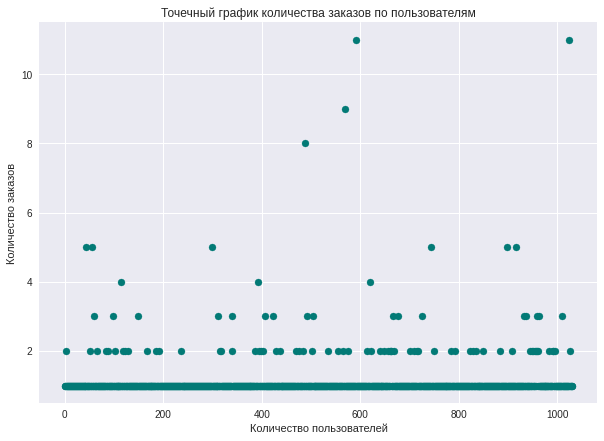

In [29]:
#зададим размер графика
plt.figure(figsize=(10, 7))
#строим точечный график количества заказов по пользователям
x_values = pd.Series(range(0, len(orders_by_users)))
plt.scatter(x_values, orders_by_users['orders'], color='#027A76')
plt.title('Точечный график количества заказов по пользователям')
plt.ylabel('Количество заказов')
plt.xlabel('Количество пользователей')
plt.show()

Большинство покупателей делали по 1-2 заказа. Покупателей, делавших 3 заказа и более совсем немного. Возможно, это и есть наши аномальные пользователи.

### Определение границы аномальных пользователей

Для того, чтобы определить границу аномальных пользователей необходимо расчитать 95-й и 99-й перцентили количества заказов на пользователя.

In [30]:
#расчитаем 90-й, 95-й и 99-й перцентили
print(f'90-й, 95-й и 99-й перцентили количества заказов на пользователя равны соответственно:', np.percentile(orders_by_users['orders'], [90, 95, 99]))

90-й, 95-й и 99-й перцентили количества заказов на пользователя равны соответственно: [1. 2. 4.]


Из расчетов видим, что не более 5% покупателей совершили 2 и более покупок и не более 1% покупателей оформили более 4 заказов. Исходя из этого, за верхнюю границу числа заказов целесообразно считать 2 заказа на одного пользователя, и отсеять аномальных пользователей по ней.

### График стоимостей заказов

Выведем таблицу с заказами отсортированными по выручке.

In [31]:
#выводим первые 10 строк отсортированной таблицы с заказами
display(orders.sort_values(by='revenue', ascending=False).head(10))

,transaction_id,visitor_id,date,revenue,group
425,590470918,1920142716,2019-08-19,1294500,B
1196,3936777065,2108080724,2019-08-15,202740,B
858,192721366,1316129916,2019-08-27,93940,A
1136,666610489,1307669133,2019-08-13,92550,A
744,3668308183,888512513,2019-08-27,86620,B
682,1216533772,4266935830,2019-08-29,78990,B
662,1811671147,4266935830,2019-08-29,78990,A
743,3603576309,4133034833,2019-08-09,67990,A
1103,1348774318,1164614297,2019-08-12,66350,A
1099,316924019,148427295,2019-08-12,65710,A


Построим и изучим гистограмму распределения стоимостей заказов.

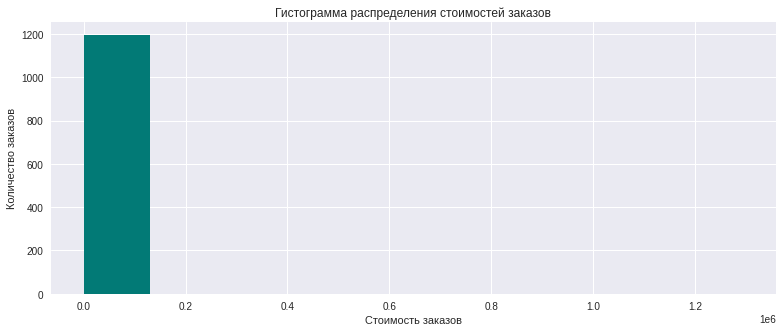

In [32]:
#зададим размер графика
plt.figure(figsize=(13, 5))
#строим гистограмму распределения стоимостей заказов
plt.hist(orders['revenue'], color='#027A76')
plt.title('Гистограмма распределения стоимостей заказов')
plt.ylabel('Количество заказов')
plt.xlabel('Стоимость заказов')
plt.show()

По гистограмме видим, что большая часть заказов приходится на сумму менее 200000 рублей. Но по гистограмме ничего не ясно. Поэтому построим точечный график и посмотрим реальное распределение.

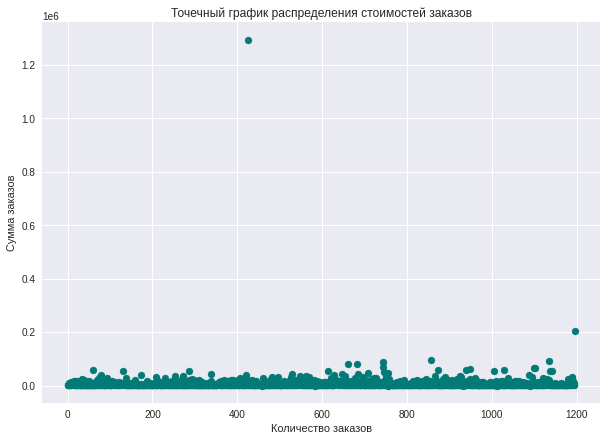

In [33]:
#зададим размер графика
plt.figure(figsize=(10, 7))
#строим точечный график стоимостей заказов
x_values = pd.Series(range(0, len(orders['revenue'])))
plt.scatter(x_values, orders['revenue'], color='#027A76')
plt.title('Точечный график распределения стоимостей заказов')
plt.ylabel('Сумма заказов')
plt.xlabel('Количество заказов')
plt.show()

Судя по графику, основная часть заказов лежит в пределах 150 000 рублей. Есть 2 видимых аномальных заказа в области 200 000 рублей и 1 225 000 рублей. Заказы на 1 225 000 рублей для интернет-магазина выглядят не совсем реально.

### Определение границы аномальных заказов

Для определения границы аномальных заказов произведем расчет 95-го и 99-го перцентилей стоимости заказов.

In [34]:
#расчитаем 90-й, 95-й и 99-й перцентили
print(f'90-й, 95-й и 99-й перцентили стоимости заказов равны соответственно:', np.percentile(orders['revenue'], [90, 95, 99]))

90-й, 95-й и 99-й перцентили стоимости заказов равны соответственно: [18168.  28000.  58233.2]


Исходя из расчета, не более 5% пользователей совершали заказы на сумму до 28 000 рублей, и не более 1% пользователей - на сумму более 58 234 рубля. Таким образом, ориентируясь на расчеты, за верхнюю границу стоимости заказов можно принять 28 000 рублей.

### Статистическая значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным

Посчитаем статистическую значимость различий в среднем числе заказов на посетителя между группами по «сырым» данным.

Сформулируем гипотезы:

**Нулевая гипотеза (Н0):** Различий в среднем количестве заказов между группами нет.

**Альтернативная гипотеза (Н1):** Различия в среднем количестве заказов между группами есть.

Подготовим данные.

In [35]:
#подготавливаем данные
visitors_A_dialy = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitors_A_dialy.columns = ['date', 'visitors_per_date_A']

visitors_A_cumulative = visitors_A_dialy.apply(
    lambda x: visitors_A_dialy[visitors_A_dialy['date'] <= x['date']].agg(\
        {'date': 'max', 'visitors_per_date_A': 'sum'}
    ),
    axis=1,
)
visitors_A_cumulative.columns = ['date', 'visitors_cumulative_A']

visitors_B_dialy = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitors_B_dialy.columns = ['date', 'visitors_per_date_B']

visitors_B_cumulative = visitors_B_dialy.apply(
    lambda x: visitors_B_dialy[visitors_B_dialy['date'] <= x['date']].agg(\
        {'date': 'max', 'visitors_per_date_B': 'sum'}
    ),
    axis=1,
)
visitors_B_cumulative.columns = ['date', 'visitors_cumulative_B']


orders_A_dialy = (
    orders[orders['group'] == 'A'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index = False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
)
orders_A_dialy.columns = ['date', 'orders_per_date_A', 'revenue_per_date_A']

orders_A_cumulative = orders_A_dialy.apply(\
    lambda x: orders_A_dialy[orders_A_dialy['date'] <= x['date']].agg(\
        {'date': 'max', 'orders_per_date_A': 'sum', 'revenue_per_date_A': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
orders_A_cumulative.columns = ['date', 'orders_cumulative_A', 'revenue_cumulative_A']

orders_B_dialy = (
    orders[orders['group'] == 'B'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index = False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
)
orders_B_dialy.columns = ['date', 'orders_per_date_B', 'revenue_per_date_B']

orders_B_cumulative = orders_B_dialy.apply(\
    lambda x: orders_B_dialy[orders_B_dialy['date'] <= x['date']].agg(\
        {'date': 'max', 'orders_per_date_B': 'sum', 'revenue_per_date_B': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
orders_B_cumulative.columns = ['date', 'orders_cumulative_B', 'revenue_cumulative_B']

cum_data = (
    orders_A_dialy.merge(
        orders_B_dialy, left_on='date', right_on='date', how='left'
    )
    .merge(orders_A_cumulative, left_on='date', right_on='date', how='left')
    .merge(orders_B_cumulative, left_on='date', right_on='date', how='left')
    .merge(visitors_A_dialy, left_on='date', right_on='date', how='left')
    .merge(visitors_B_dialy, left_on='date', right_on='date', how='left')
    .merge(visitors_A_cumulative, left_on='date', right_on='date', how='left')
    .merge(visitors_B_cumulative, left_on='date', right_on='date', how='left')
)
display(cum_data.head(5))

,date,orders_per_date_A,revenue_per_date_A,orders_per_date_B,revenue_per_date_B,orders_cumulative_A,revenue_cumulative_A,orders_cumulative_B,revenue_cumulative_B,visitors_per_date_A,visitors_per_date_B,visitors_cumulative_A,visitors_cumulative_B
0,2019-08-01,24,148579,21,101217,24,148579,21,101217,719,713,719,713
1,2019-08-02,20,93822,24,165531,44,242401,45,266748,619,581,1338,1294
2,2019-08-03,24,112473,16,114248,68,354874,61,380996,507,509,1845,1803
3,2019-08-04,16,70825,17,108571,84,425699,78,489567,717,770,2562,2573
4,2019-08-05,25,124218,23,92428,109,549917,101,581995,756,707,3318,3280


Объявим переменные `orders_by_users_A` и `orders_by_users_B`, где для пользователей, которые заказывали хотя бы 1 раз, укажем число совершённых заказов. 

In [36]:
orders_by_users_A = (
    orders[orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
orders_by_users_A.columns = ['visitor_id', 'orders']

orders_by_users_B = (
    orders[orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
orders_by_users_B.columns = ['visitor_id', 'orders']

Объявим переменные `sample_A` и `sample_B`, где пользователям из разных групп будет соответствовать количество заказов. Тем, кто ничего не заказал, будут соответствовать нули.

In [37]:
sample_A = pd.concat(
    [
        orders_by_users_A['orders'],
        pd.Series(
            0,
            index=np.arange(
                cum_data['visitors_per_date_A'].sum() - len(orders_by_users_A['orders'])
            ),
            name='orders',
        )
    ],
    axis=0,
)

sample_B = pd.concat(
    [
        orders_by_users_B['orders'],
        pd.Series(
            0,
            index=np.arange(
                cum_data['visitors_per_date_B'].sum() - len(orders_by_users_B['orders'])
            ),
            name='orders',
        )
    ],
    axis=0,
)

Теперь посчитаем статистическую значимость различия среднего количества заказов по результатам теста, а также относительное различие в среднем между группами.

In [38]:
alpha = 0.05
#считаем статистическую значимость различия среднего количества заказов
p_value = stats.mannwhitneyu(sample_A, sample_B)[1]
#считаем относительное различие в среднем между группами
orders_group_dif = sample_B.mean() / sample_A.mean() - 1

print('Статистическая значимость различия среднего количества заказов равна:', p_value.round(3))
print('Относительное различие в среднем количестве заказов между группами равно:', orders_group_dif.round(3))
if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Статистическая значимость различия среднего количества заказов равна: 0.017
Относительное различие в среднем количестве заказов между группами равно: 0.138
Отвергаем нулевую гипотезу


Значение p-value, равное 0,017, значительно меньше 0,05, поэтому нулевую гипотезу о том, что различий в среднем количестве заказов между группами нет, мы отвергаем. В среднем количестве заказов между группами есть статистически значимые различия. Относительный прирост среднего количества заказов группы В к группе А равен 13,8%.

### Статистическая значимость различий в среднем чеке заказа между группами по «сырым» данным

Расчитаем статистическую значимость различий в среднем чеке заказа между группами по "сырым" данным.

Сформулируем гипотезы:

**Нулевая гипотеза (Н0):** Различий в среднем чеке между группами нет.

**Альтернативная гипотеза (Н1):** Различия в среднем чеке между группами есть.

In [39]:
alpha=0.05
#расчитаем статистическую значимость различий в среднем чеке заказа
p_value = stats.mannwhitneyu(orders[orders['group'] == 'A']['revenue'],\
    orders[orders['group'] == 'B']['revenue'])[1]
#paсчитаем относительное различие в среднем чеке между группами
revenue_group_dif = orders[orders['group'] == 'B']['revenue'].mean()/\
    orders[orders['group'] == 'A']['revenue'].mean() - 1

print('Статистическая значимость различий в среднем чеке заказа по группам равна:', p_value.round(3))
print('Относительное различие в среднем чеке между группами равно:', revenue_group_dif.round(3))
if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Статистическая значимость различий в среднем чеке заказа по группам равна: 0.729
Относительное различие в среднем чеке между группами равно: 0.259
Не получилось отвергнуть нулевую гипотезу


Значение p-value достаточно высокое - 0,729, и намного выше 0,05, поэтому нулевую гипотезу о том, что статистически значимых различий в среднем чеке между группами нет, мы не можем отвергнуть. Однако, относительное различие в среднем чеке между группами составило 25,9%. Необходимо проанализировать аномалии.

### Статистическая значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

Создадим список аномальных пользователей по выявленным признакам. Для этого удалим пользователей с количеством заказов больше 2 и суммой заказа выше 28 000 рублей.

In [40]:
#отсеиваем пользователей с количеством заказов больше 2
users_with_many_orders = pd.concat(
    [
        orders_by_users_A[orders_by_users_A['orders'] > 2]['visitor_id'],
        orders_by_users_B[orders_by_users_B['orders'] > 2]['visitor_id']
    ],
    axis=0,
)
#отсеиваем пользователей с суммой заказа больше 28 000 рублей
users_with_expensive_orders = orders[orders['revenue'] > 28000]['visitor_id']
#объединяем и избавляемся от дублей
abnormal_users = (
    pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0)
    .drop_duplicates()
    .sort_values()
)
#выведем полученные данные
display(abnormal_users.head(5))
print('Количество аномальных пользователей:', abnormal_users.shape[0])

1099    148427295
18      199603092
928     204675465
23      237748145
37      249864742
Name: visitor_id, dtype: int64

Количество аномальных пользователей: 74


Посчитаем статистическую значимость различий в среднем количестве заказов между группами теста по "очищенным" данным.

Сформулируем гипотезы:

**Нулевая гипотеза (Н0):** Различий в среднем количестве заказов на посетителя между группами по «очищенным» данным нет.

**Альтернативная гипотеза (Н1):** Различия в среднем количестве заказов на посетителя между группами по «очищенным» данным есть.

In [41]:
#сохраним очищенные данные о заказах — не включая аномальных пользователей
sample_A_filtered = pd.concat(
    [
        orders_by_users_A[
            np.logical_not(orders_by_users_A['visitor_id'].isin(abnormal_users))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                cum_data['visitors_per_date_A'].sum() - len(orders_by_users_A['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sample_B_filtered = pd.concat(
    [
        orders_by_users_B[
            np.logical_not(orders_by_users_B['visitor_id'].isin(abnormal_users))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                cum_data['visitors_per_date_B'].sum() - len(orders_by_users_B['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

Посчитаем статистическую значимость различий в среднем количестве заказов между группами теста по "очищенным" данным.

In [42]:
alpha = 0.05
#считаем статистическую значимость различия среднего количества заказов между группами теста по "очищенным" данным
p_value = stats.mannwhitneyu(sample_A_filtered, sample_B_filtered)[1]
#считаем относительное различие среднего количества заказов между группами теста по "очищенным" данным
orders_group_filtered_dif = sample_B_filtered.mean() / sample_A_filtered.mean() - 1

print('Статистическая значимость различия среднего количества заказов между группами теста по "очищенным" данным равна:', p_value.round(3))
print('Относительное различие среднего количества заказов между группами теста по "очищенным" данным равно:', orders_group_filtered_dif.round(3))
if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Статистическая значимость различия среднего количества заказов между группами теста по "очищенным" данным равна: 0.013
Относительное различие среднего количества заказов между группами теста по "очищенным" данным равно: 0.173
Отвергаем нулевую гипотезу


При анализе различий среднего количества заказов по "очищенным" данным картина поменялась совсем незначительно. P-value стал равен 0,013, что все еще ниже 0,05, соответственно нулевая гипотеза о том, что различий нет, отвергается. При этом относительный прирост среднего количества заказов группы В к группе А равен 17,3%.

### Cтатистическая значимость различий в среднем чеке заказа между группами по «очищенным» данным

Расчитаем статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным.

Сформулируем гипотезы:

**Нулевая гипотеза (Н0):** Различий в среднем чеке заказа между группами по «очищенным» данным нет.

**Альтернативная гипотеза (Н1):** Различия в среднем чеке заказа между группами по «очищенным» данным есть.

In [43]:
alpha=0.05
#расчитаем статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным
p_value = stats.mannwhitneyu(
    orders[
        np.logical_and(
            orders['group'] == 'A',
            np.logical_not(orders['visitor_id'].isin(abnormal_users)),
        )
    ]['revenue'],
    orders[
        np.logical_and(
            orders['group'] == 'B',
            np.logical_not(orders['visitor_id'].isin(abnormal_users)),
        )
    ]['revenue'],
)[1]
#paсчитаем относительное различие в среднем чеке между группами по «очищенным» данным
revenue_group_filtered_dif = orders[np.logical_and(orders['group'] == 'B', np.logical_not(orders['visitor_id'].isin\
            (abnormal_users)),)]['revenue'].mean() / orders[np.logical_and(orders['group'] == 'A',\
            np.logical_not(orders['visitor_id'].isin(abnormal_users)),)]['revenue'].mean() - 1

print('Cтатистическая значимость различий в среднем чеке заказа между группами по «очищенным» данным равна:', p_value.round(3))
print('Относительное различие в среднем чеке между группами по «очищенным» данным равно:', revenue_group_filtered_dif.round(3))
if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Cтатистическая значимость различий в среднем чеке заказа между группами по «очищенным» данным равна: 0.738
Относительное различие в среднем чеке между группами по «очищенным» данным равно: -0.02
Не получилось отвергнуть нулевую гипотезу


Значение p-value, равное 0,738, как и в случае с "сырыми" данными, намного превышает 0,05, что говорит о том, что нулевую гипотезу, предполагающую отстуствие различий в среднем чеке заказа между группами по «очищенным» данным, мы не можем отвергнуть. А вот различие между группами А и В сократилось с 25,9% до 2%, что показывает, как сильно выбросы повлияли на результаты.

## Выводы и решения по результатам теста

В данном исследовании мы провели приоритизацию гипотез, а также проанализировали результаты А/В-теста.

Проведя приоритизацию гипотез фреймворками ICE и RICE, и , выделив лидеров среди гипотез, можем рекомендовать к тестированию гипотезы **№7 «Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок»** и **№0 «Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей»**.

У гипотезы №7 самый высокий балл Reach, что говорит о том, что изменения затронут очень много пользователей, высокий балл влияния на пользователей и уверенности в том, что изменения повлияют положительно, так же средний балл на затраты для ее тестирования.

У гипотезы №0 параметр Reach низковат, что значит, что изменения затронут немногих пользователей, но при этом высший балл по влиянию на пользователя и высокий балл уверенности в этом влиянии, при этом затраты на ее тестирования также на среднем уровне.

По результатам А/В-теста обнаружили следующие моменты:

* Есть статистически значимые различия по среднему количеству заказов между сегментами А и В, как по «сырым», так и по данным после фильтрации аномалий. По «сырым» данным относительный прирост среднего количества заказов группы В к группе А равен 13,8%, а по отфильтрованным - 17,3%.
* По данным проверки теста, статистически значимого различия по среднему чеку между группами ни по «сырым», ни по «очищенным» данным нет. При этом относительное различие по среднему чеку по «сырым» данным  сегмента В к сегменту А составило 25,9%, но после фильтрации сократилось до 2%, что говорит о сильном влиянии аномально дорогих заказов.
* По данным графика различия среднего количества заказов между группами можно сказать, что результаты группы В в разы превышали результаты группы А с заметной тенденцией к улучшению в последние дни тестирования.
* График различия среднего чека колеблется, имеет большие всплески в начале и после середины теста. Делать по нему какие-либо выводы сложно, но он указал нам на имеющиеся аномалии.
* Почти на протяжении всего теста группа В имела лучшие результаты по отношению к группе А, за исключением начала теста.

Исходя из вышеперечисленного, группа В имеет лучше потенциал для привлечения пользователей, чем группа А. При этом некие доработки все же необходимы. Стоит еще проанализировать первую часть теста, почему там показатели группы А лучше, а группы В хуже.

И все же, **тест рекомендуем завершить и признать его частично успешным, применять настройки группы В как минимальные, в дальнейшем доработать**.